# Band width vs parameter count (bkg_penalty ON)

1 eV, `bkg_penalty=True`. Sweep the number of flux parameters
`n` (= CRmat columns via `intervals`) and look at how the confidence-band
width changes. The data bin count `m = 29` is fixed, so smaller `n` means
less underdetermination.

Band width is measured at a few fixed physical energies (the index nearest
each target energy), for both scenarios **a (No Bkg)** and **b (Exp Bkg)**,
at 1σ (0.678) and 2σ (0.954).

Data produced by `run_param_scan.py` → `param_scan_results.json`.
Run this notebook from `1eV/` or from `1eV/param_scan_bkgpen/`.


In [9]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# locate the results file whether run from 1eV/ or from the scan folder
CANDS = ['param_scan_bkgpen/param_scan_results.json', 'param_scan_results.json']
PATH = next((p for p in CANDS if os.path.exists(p)), None)
assert PATH, f'param_scan_results.json not found (looked in {CANDS})'
df = pd.DataFrame(json.load(open(PATH)))
NORM = 1e12
SCEN_LABEL = {'a': 'No Bkg', 'b': 'Exp Bkg'}
df['scenario_label'] = df['scenario'].map(lambda s: SCEN_LABEL.get(s, f'bkg {s}'))
df['width_n'] = df['width'] / NORM
print(f'loaded {len(df)} records from {PATH}')
print('n      :', sorted(df.n.unique()))
print('E targ :', sorted(df.target_E.unique()))
print('levels :', sorted(df.level.unique()))
df.head()


loaded 144 records from param_scan_results.json
n      : [np.int64(10), np.int64(20), np.int64(31), np.int64(40), np.int64(50), np.int64(60), np.int64(80), np.int64(100), np.int64(120), np.int64(140), np.int64(160), np.int64(180)]
E targ : [np.float64(0.4), np.float64(0.6), np.float64(0.9)]
levels : [np.float64(0.678), np.float64(0.954)]


,scenario,n,target_E,idx,E,level,lower,upper,width,best_fit,bkg_penalty,scenario_label,width_n
0,a,10,0.4,1,0.382222,0.678,9.267324e+11,1.194019e+12,2.672870e+11,1.065248e+12,True,No Bkg,0.267287
1,a,10,0.4,1,0.382222,0.954,8.373972e+11,1.288334e+12,4.509368e+11,1.065248e+12,True,No Bkg,0.450937
2,a,10,0.6,2,0.584444,0.678,7.648142e+11,9.854010e+11,2.205868e+11,8.791287e+11,True,No Bkg,0.220587
3,a,10,0.6,2,0.584444,0.954,7.088247e+11,1.063237e+12,3.544123e+11,8.791287e+11,True,No Bkg,0.354412
4,a,10,0.9,4,0.988889,0.678,4.534212e+11,6.465195e+11,1.930984e+11,5.482892e+11,True,No Bkg,0.193098


In [10]:
# width [1e12 cm^-2 s^-1] as a table: rows = (scenario, target_E, level), cols = n
piv = df.pivot_table(index=['scenario_label', 'target_E', 'level'],
                     columns='n', values='width_n')
piv.round(4)


n                                 10      20      31      40      50      60   \
scenario_label target_E level                                                   
Exp Bkg        0.4      0.678  0.3752  0.5128  0.5236  0.5337  0.5401  0.5775   
                        0.954  0.5792  0.8075  0.7706  0.8250  0.8350  0.8778   
               0.6      0.678  0.2837  0.4192  0.4176  0.4749  0.4853  0.4938   
                        0.954  0.4903  0.6277  0.6145  0.6628  0.6603  0.6638   
               0.9      0.678  0.2491  0.3502  0.4015  0.4304  0.4278  0.4375   
                        0.954  0.3825  0.5089  0.5568  0.5512  0.5813  0.5559   
No Bkg         0.4      0.678  0.2673  0.3978  0.4332  0.4766  0.4593  0.4602   
                        0.954  0.4509  0.6300  0.5993  0.6490  0.6568  0.6962   
               0.6      0.678  0.2206  0.3251  0.3549  0.3829  0.3913  0.4023   
                        0.954  0.3544  0.4846  0.5074  0.5214  0.5497  0.5399   
               0.9      0.678  0.1931  0.3092  0.3565  0.3529  0.3625  0.3825   
                        0.954  0.3160  0.4305  0.4684  0.4744  0.5046  0.5032   

n                                 80      100     120     140     160     180  
scenario_label target_E level                                                  
Exp Bkg        0.4      0.678  0.5983  0.5761  0.5758  0.5977  0.5759  0.5991  
                        0.954  0.8763  0.9179  0.9608  0.9176  0.9609  0.9493  
               0.6      0.678  0.5038  0.5065  0.5072  0.5064  0.5232  0.5079  
                        0.954  0.6773  0.6959  0.6818  0.6808  0.6955  0.7141  
               0.9      0.678  0.4286  0.4340  0.4292  0.4250  0.4501  0.4399  
                        0.954  0.6009  0.5608  0.6019  0.5959  0.6098  0.5968  
No Bkg         0.4      0.678  0.4824  0.4821  0.4942  0.4819  0.4943  0.4967  
                        0.954  0.6568  0.6946  0.7333  0.6943  0.7335  0.7328  
               0.6      0.678  0.4106  0.4126  0.4133  0.4126  0.4303  0.4156  
                        0.954  0.5676  0.5400  0.5714  0.5703  0.5701  0.5730  
               0.9      0.678  0.3957  0.3908  0.3752  0.3924  0.4069  0.3930  
                        0.954  0.5156  0.5092  0.5263  0.5113  0.5254  0.5128

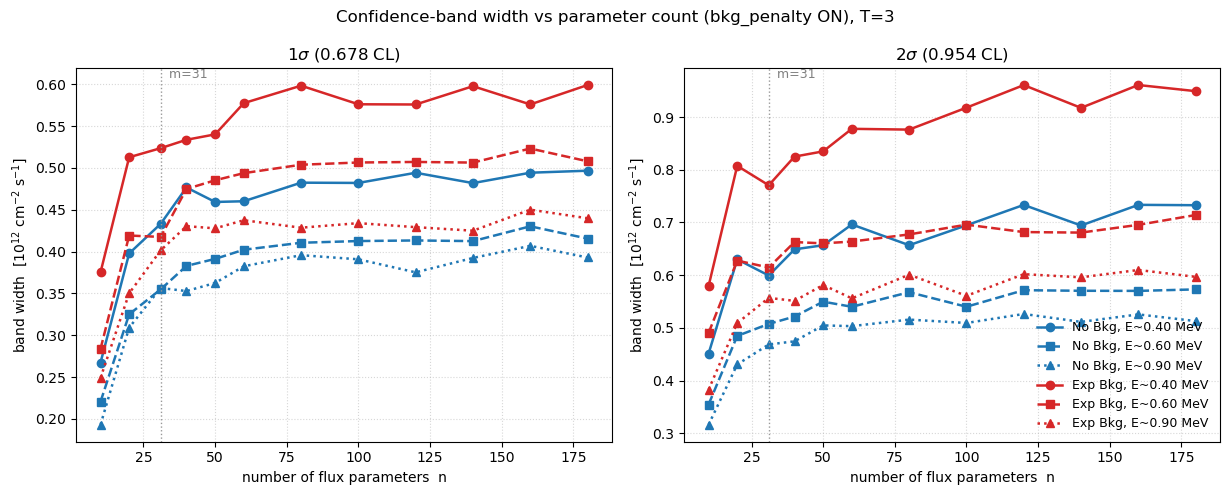

saved width_vs_n.pdf


In [11]:
# band width vs n: one subplot per confidence level
levels  = sorted(df.level.unique())
scens   = sorted(df.scenario.unique())
targets = sorted(df.target_E.unique())
scen_color = {s: c for s, c in zip(scens, ['C0', 'C3', 'C2', 'C1'])}
targ_ls    = {E: ls for E, ls in zip(targets, ['-', '--', ':', '-.'])}
targ_mk    = {E: mk for E, mk in zip(targets, ['o', 's', '^', 'D'])}

fig, axes = plt.subplots(1, len(levels), figsize=(6.2 * len(levels), 5),
                         squeeze=False)
for ax, lv in zip(axes[0], levels):
    for s in scens:
        for E in targets:
            sub = df[(df.scenario == s) & (df.target_E == E) &
                     (df.level == lv)].sort_values('n')
            if sub.empty:
                continue
            ax.plot(sub.n, sub.width_n, color=scen_color[s],
                    ls=targ_ls[E], marker=targ_mk[E], lw=1.8, ms=6,
                    label=f'{SCEN_LABEL.get(s, s)}, E~{E:.2f} MeV')
    nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
    ax.set_title(rf'{nsig}$\sigma$ ({lv:.3f} CL)')
    ax.set_xlabel('number of flux parameters  n')
    ax.set_ylabel(r'band width  [$10^{12}$ cm$^{-2}$ s$^{-1}$]')
    ax.axvline(31, color='0.6', ls=':', lw=1)      # data bin count m = 31
    ax.text(31, ax.get_ylim()[1], '  m=31', color='0.5', va='top', fontsize=9)
    ax.grid(ls=':', alpha=0.5)
ax.legend(frameon=False, fontsize=9)
fig.suptitle('Confidence-band width vs parameter count (bkg_penalty ON), T=3')
fig.tight_layout()
fig.savefig('param_scan_bkgpen/width_vs_n.pdf' if os.path.isdir('param_scan_bkgpen')
            else 'width_vs_n.pdf')
plt.show()
print('saved width_vs_n.pdf')


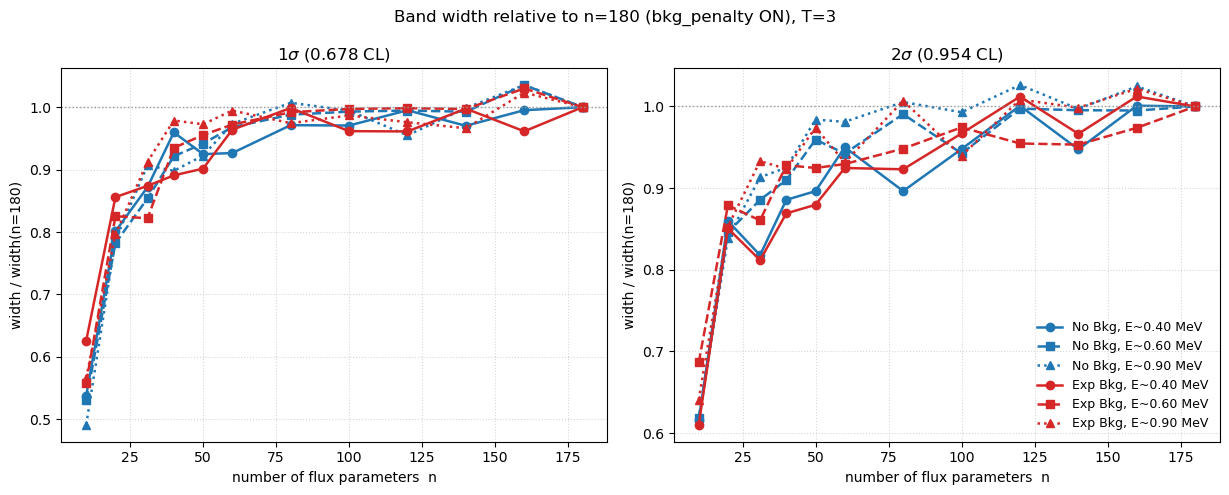

In [12]:
# same, normalised to the largest n (relative change as parameters drop)
n_ref = df.n.max()
fig, axes = plt.subplots(1, len(levels), figsize=(6.2 * len(levels), 5),
                         squeeze=False)
for ax, lv in zip(axes[0], levels):
    for s in scens:
        for E in targets:
            sub = df[(df.scenario == s) & (df.target_E == E) &
                     (df.level == lv)].sort_values('n')
            if sub.empty:
                continue
            ref = sub[sub.n == n_ref]['width'].values
            if not len(ref) or ref[0] == 0:
                continue
            ax.plot(sub.n, sub['width'] / ref[0], color=scen_color[s],
                    ls=targ_ls[E], marker=targ_mk[E], lw=1.8, ms=6,
                    label=f'{SCEN_LABEL.get(s, s)}, E~{E:.2f} MeV')
    nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
    ax.set_title(rf'{nsig}$\sigma$ ({lv:.3f} CL)')
    ax.set_xlabel('number of flux parameters  n')
    ax.set_ylabel(f'width / width(n={n_ref})')
    ax.axhline(1.0, color='0.6', ls=':', lw=1)
    ax.grid(ls=':', alpha=0.5)
ax.legend(frameon=False, fontsize=9)
fig.suptitle(f'Band width relative to n={n_ref} (bkg_penalty ON), T=3')
fig.tight_layout()
plt.show()


In [13]:
# asymmetric deviations from best-fit, per energy
df['err_up'] = (df['upper'] - df['best_fit']) / NORM   # upper band - best-fit
df['err_lo'] = (df['best_fit'] - df['lower']) / NORM   # best-fit - lower band

piv = df.pivot_table(index=['scenario_label', 'target_E', 'level'], columns='n',
                     values=['err_up', 'err_lo'])
piv = piv.swaplevel(0, 1, axis=1).sort_index(axis=1)   # group by n, then side
print('upper (hi-bf) / lower (bf-lo) deviation  [1e12 cm^-2 s^-1]:')
piv.round(4)


upper (hi-bf) / lower (bf-lo) deviation  [1e12 cm^-2 s^-1]:


n                                 10              20              31           \
                               err_lo  err_up  err_lo  err_up  err_lo  err_up   
scenario_label target_E level                                                   
Exp Bkg        0.4      0.678  0.1843  0.1909  0.2414  0.2714  0.2304  0.2933   
                        0.954  0.2892  0.2901  0.3470  0.4605  0.3311  0.4395   
               0.6      0.678  0.1521  0.1316  0.1974  0.2219  0.2057  0.2118   
                        0.954  0.2222  0.2681  0.2837  0.3440  0.2861  0.3284   
               0.9      0.678  0.1173  0.1318  0.1706  0.1796  0.2016  0.1999   
                        0.954  0.1781  0.2044  0.2474  0.2616  0.2656  0.2912   
No Bkg         0.4      0.678  0.1385  0.1288  0.1954  0.2024  0.2082  0.2250   
                        0.954  0.2279  0.2231  0.2855  0.3445  0.2716  0.3277   
               0.6      0.678  0.1143  0.1063  0.1597  0.1654  0.1705  0.1844   
                        0.954  0.1703  0.1841  0.2333  0.2513  0.2390  0.2685   
               0.9      0.678  0.0949  0.0982  0.1489  0.1604  0.1780  0.1785   
                        0.954  0.1488  0.1672  0.2109  0.2196  0.2240  0.2444   

n                                 40              50           ...     100  \
                               err_lo  err_up  err_lo  err_up  ...  err_lo   
scenario_label target_E level                                  ...           
Exp Bkg        0.4      0.678  0.2348  0.2989  0.3561  0.1840  ...  0.3560   
                        0.954  0.3375  0.4875  0.4601  0.3749  ...  0.4598   
               0.6      0.678  0.2286  0.2463  0.2105  0.2748  ...  0.1847   
                        0.954  0.2938  0.3691  0.2927  0.3677  ...  0.2804   
               0.9      0.678  0.2108  0.2196  0.2095  0.2183  ...  0.2021   
                        0.954  0.2629  0.2883  0.2709  0.3104  ...  0.2613   
No Bkg         0.4      0.678  0.2127  0.2640  0.3107  0.1486  ...  0.3335   
                        0.954  0.2775  0.3715  0.3993  0.2575  ...  0.3991   
               0.6      0.678  0.1935  0.1894  0.1746  0.2167  ...  0.1494   
                        0.954  0.2455  0.2758  0.2446  0.3050  ...  0.2182   
               0.9      0.678  0.1762  0.1767  0.1869  0.1756  ...  0.1802   
                        0.954  0.2324  0.2419  0.2414  0.2632  ...  0.2328   

n                                         120             140             160  \
                               err_up  err_lo  err_up  err_lo  err_up  err_lo   
scenario_label target_E level                                                   
Exp Bkg        0.4      0.678  0.2201  0.3558  0.2200  0.3776  0.2201  0.3558   
                        0.954  0.4581  0.4596  0.5012  0.4596  0.4579  0.4597   
               0.6      0.678  0.3218  0.2071  0.3001  0.1846  0.3218  0.2015   
                        0.954  0.4155  0.2880  0.3938  0.2654  0.4154  0.2802   
               0.9      0.678  0.2320  0.2102  0.2190  0.2081  0.2169  0.2314   
                        0.954  0.2994  0.2904  0.3115  0.2875  0.3084  0.2988   
No Bkg         0.4      0.678  0.1485  0.3104  0.1838  0.3334  0.1485  0.3105   
                        0.954  0.2955  0.3989  0.3344  0.3989  0.2954  0.3990   
               0.6      0.678  0.2633  0.1718  0.2415  0.1493  0.2632  0.1671   
                        0.954  0.3218  0.2408  0.3307  0.2181  0.3522  0.2181   
               0.9      0.678  0.2106  0.1990  0.1762  0.1970  0.1954  0.2099   
                        0.954  0.2764  0.2622  0.2641  0.2498  0.2615  0.2618   

n                                         180          
                               err_up  err_lo  err_up  
scenario_label target_E level                          
Exp Bkg        0.4      0.678  0.2201  0.3361  0.2630  
                        0.954  0.5012  0.4376  0.5117  
               0.6      0.678  0.3217  0.2789  0.2290  
                        0.954  0.4152  0.3591  0.3551  
     

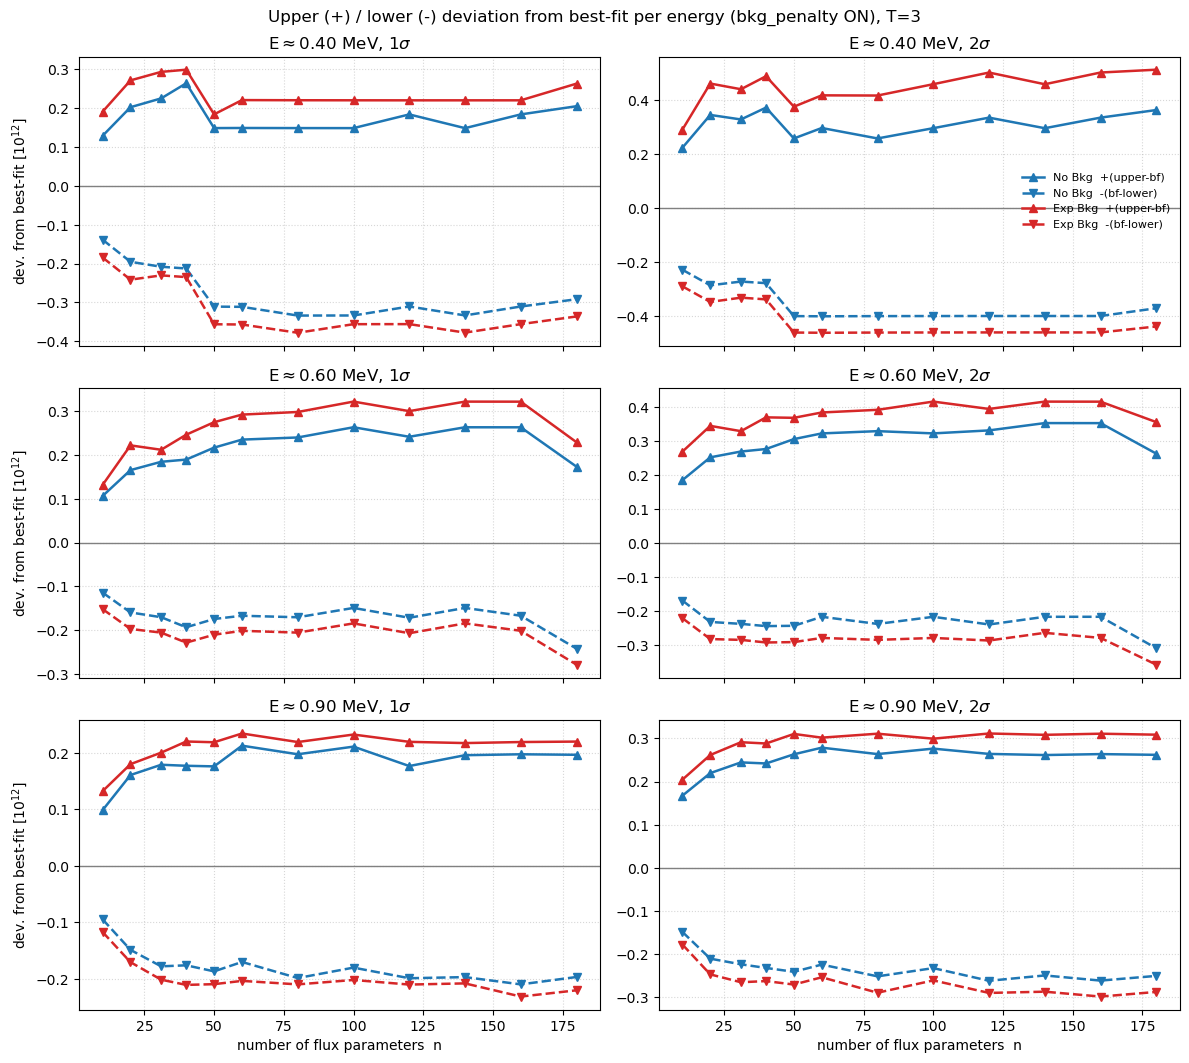

saved dev_from_bestfit_vs_n.pdf


In [14]:
# upper (+, hi-bf) and lower (-, bf-lo) deviation vs n, faceted by energy x level
levels  = sorted(df.level.unique())
targets = sorted(df.target_E.unique())
scens   = sorted(df.scenario.unique())
scen_color = {s: c for s, c in zip(scens, ['C0', 'C3', 'C2', 'C1'])}

fig, axes = plt.subplots(len(targets), len(levels),
                         figsize=(6.0 * len(levels), 3.6 * len(targets)),
                         squeeze=False, sharex=True)
for ri, E in enumerate(targets):
    for ci, lv in enumerate(levels):
        ax = axes[ri][ci]
        for s in scens:
            sub = df[(df.scenario == s) & (df.target_E == E) &
                     (df.level == lv)].sort_values('n')
            if sub.empty:
                continue
            c = scen_color[s]
            ax.plot(sub.n,  sub.err_up, color=c, ls='-',  marker='^', lw=1.8,
                    ms=6, label=f'{SCEN_LABEL.get(s, s)}  +(upper-bf)')
            ax.plot(sub.n, -sub.err_lo, color=c, ls='--', marker='v', lw=1.8,
                    ms=6, label=f'{SCEN_LABEL.get(s, s)}  -(bf-lower)')
        ax.axhline(0, color='0.5', lw=1)               # best-fit reference
        nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
        ax.set_title(rf'E$\approx${E:.2f} MeV, {nsig}$\sigma$')
        ax.grid(ls=':', alpha=0.5)
        if ci == 0:
            ax.set_ylabel(r'dev. from best-fit [$10^{12}$]')
        if ri == len(targets) - 1:
            ax.set_xlabel('number of flux parameters  n')
axes[0][-1].legend(frameon=False, fontsize=8)
fig.suptitle('Upper (+) / lower (-) deviation from best-fit per energy '
             '(bkg_penalty ON), T=3')
fig.tight_layout()
fig.savefig('param_scan_bkgpen/dev_from_bestfit_vs_n.pdf'
            if os.path.isdir('param_scan_bkgpen') else 'dev_from_bestfit_vs_n.pdf')
plt.show()
print('saved dev_from_bestfit_vs_n.pdf')


In [15]:
# 2σ - 1σ gap on each side, per energy:
#   upper = hi(2σ) - hi(1σ) = err_up(2σ) - err_up(1σ)
#   lower = lo(1σ) - lo(2σ) = err_lo(2σ) - err_lo(1σ)   (outward extent of 2σ)
df['err_up'] = (df['upper'] - df['best_fit']) / NORM
df['err_lo'] = (df['best_fit'] - df['lower']) / NORM
L1, L2 = sorted(df.level.unique())          # 1σ, 2σ

g = df.pivot_table(index=['scenario', 'scenario_label', 'target_E', 'n'],
                   columns='level', values=['err_up', 'err_lo'])
gap = pd.DataFrame({
    'gap_up': g[('err_up', L2)] - g[('err_up', L1)],
    'gap_lo': g[('err_lo', L2)] - g[('err_lo', L1)],
}).reset_index()

piv = (gap.pivot_table(index=['scenario_label', 'target_E'], columns='n',
                       values=['gap_up', 'gap_lo'])
          .swaplevel(0, 1, axis=1).sort_index(axis=1))
print(f'2sigma - 1sigma gap  [1e12 cm^-2 s^-1]   (L1={L1}, L2={L2})')
print('  gap_up = hi(2s) - hi(1s),   gap_lo = lo(1s) - lo(2s)')
piv.round(4)


2sigma - 1sigma gap  [1e12 cm^-2 s^-1]   (L1=0.678, L2=0.954)
  gap_up = hi(2s) - hi(1s),   gap_lo = lo(1s) - lo(2s)


n                           10              20              31           \
                         gap_lo  gap_up  gap_lo  gap_up  gap_lo  gap_up   
scenario_label target_E                                                   
Exp Bkg        0.4       0.1048  0.0992  0.1056  0.1891  0.1008  0.1462   
               0.6       0.0701  0.1365  0.0863  0.1221  0.0803  0.1166   
               0.9       0.0608  0.0726  0.0768  0.0820  0.0640  0.0913   
No Bkg         0.4       0.0893  0.0943  0.0900  0.1421  0.0634  0.1027   
               0.6       0.0560  0.0778  0.0736  0.0860  0.0684  0.0841   
               0.9       0.0540  0.0690  0.0621  0.0592  0.0460  0.0659   

n                           40              50           ...     100          \
                         gap_lo  gap_up  gap_lo  gap_up  ...  gap_lo  gap_up   
scenario_label target_E                                  ...                   
Exp Bkg        0.4       0.1027  0.1887  0.1039  0.1909  ...  0.1039  0.2379   
               0.6       0.0652  0.1228  0.0822  0.0929  ...  0.0957  0.0936   
               0.9       0.0522  0.0686  0.0614  0.0921  ...  0.0593  0.0675   
No Bkg         0.4       0.0648  0.1076  0.0886  0.1089  ...  0.0655  0.1469   
               0.6       0.0521  0.0864  0.0700  0.0883  ...  0.0688  0.0586   
               0.9       0.0563  0.0652  0.0545  0.0876  ...  0.0526  0.0658   

n                           120             140             160          \
                         gap_lo  gap_up  gap_lo  gap_up  gap_lo  gap_up   
scenario_label target_E                                                   
Exp Bkg        0.4       0.1038  0.2811  0.0820  0.2378  0.1038  0.2811   
               0.6       0.0809  0.0937  0.0808  0.0936  0.0787  0.0936   
               0.9       0.0802  0.0924  0.0794  0.0915  0.0674  0.0923   
No Bkg         0.4       0.0885  0.1506  0.0655  0.1469  0.0885  0.1507   
               0.6       0.0689  0.0891  0.0688  0.0890  0.0509  0.0889   
               0.9       0.0632  0.0878  0.0528  0.0661  0.0519  0.0666   

n                           180          
                         gap_lo  gap_up  
scenario_label target_E                  
Exp Bkg        0.4       0.1015  0.2487  
               0.6       0.0802  0.1260  
               0.9       0.0677  0.0892  
No Bkg         0.4       0.0784  0.1576  
               0.6       0.0685  0.0889  
               0.9       0.0540  0.0658  

[6 rows x 24 columns]

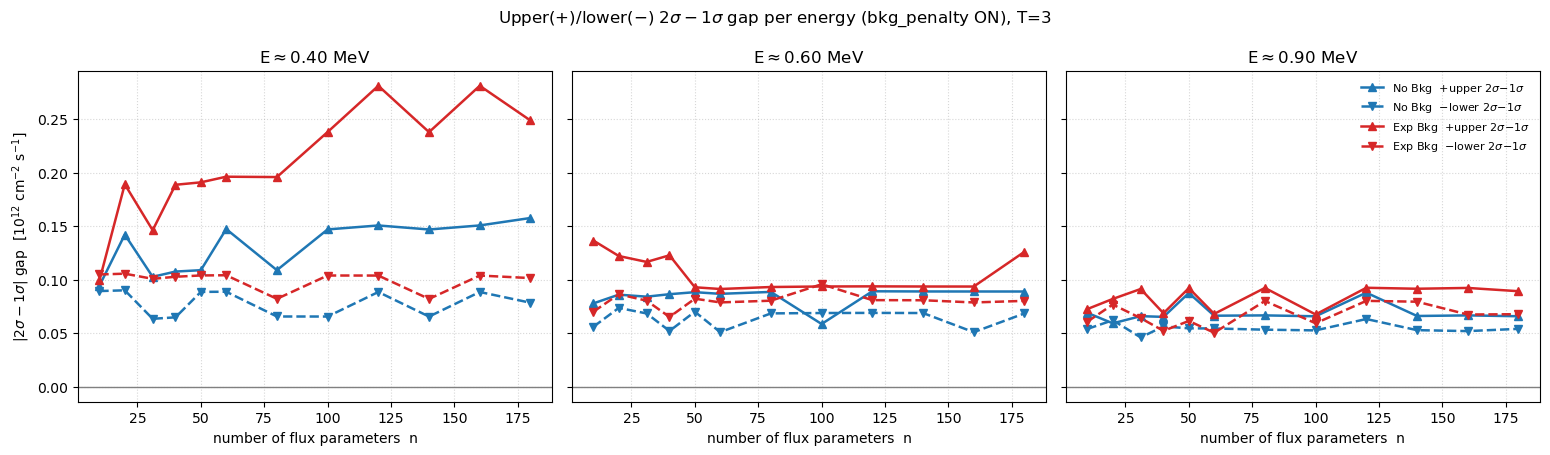

saved gap_2s_1s_vs_n.pdf


In [16]:
# 2σ-1σ gap vs n, faceted by energy: upper (+) and lower (-, drawn downward)
targets = sorted(df.target_E.unique())
scens   = sorted(df.scenario.unique())
scen_color = {s: c for s, c in zip(scens, ['C0', 'C3', 'C2', 'C1'])}

fig, axes = plt.subplots(1, len(targets), figsize=(5.2 * len(targets), 4.6),
                         squeeze=False, sharey=True)
for ci, E in enumerate(targets):
    ax = axes[0][ci]
    for s in scens:
        sub = gap[(gap.scenario == s) & (gap.target_E == E)].sort_values('n')
        if sub.empty:
            continue
        c = scen_color[s]
        ax.plot(sub.n,  sub.gap_up, color=c, ls='-',  marker='^', lw=1.8, ms=6,
                label=rf'{SCEN_LABEL.get(s, s)}  $+$upper $2\sigma\!-\!1\sigma$')
        ax.plot(sub.n, sub.gap_lo, color=c, ls='--', marker='v', lw=1.8, ms=6,
                label=rf'{SCEN_LABEL.get(s, s)}  $-$lower $2\sigma\!-\!1\sigma$')
    ax.axhline(0, color='0.5', lw=1)
    ax.set_title(rf'E$\approx${E:.2f} MeV')
    ax.set_xlabel('number of flux parameters  n')
    ax.grid(ls=':', alpha=0.5)
axes[0][0].set_ylabel(r'|$2\sigma-1\sigma$| gap  [$10^{12}$ cm$^{-2}$ s$^{-1}$]')
axes[0][-1].legend(frameon=False, fontsize=8)
fig.suptitle(r'Upper($+$)/lower($-$) $2\sigma-1\sigma$ gap per energy '
             '(bkg_penalty ON), T=3')
fig.tight_layout()
fig.savefig('param_scan_bkgpen/gap_2s_1s_vs_n.pdf'
            if os.path.isdir('param_scan_bkgpen') else 'gap_2s_1s_vs_n.pdf')
plt.show()
print('saved gap_2s_1s_vs_n.pdf')
